# Patchseq MET-type vs T-type Confusion Matrix

Load patchseq MET types and Tasic T-types from the combined delta lake,
merge on cell ID, and plot row-normalised confusion matrices with schema
colour strips alongside both axes.

In [1]:
import os
import numpy as np
import polars as pl
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import colorcet as cc

COMBINED_ROOT = "/scratch/combined_datasets"

## 1. Helper: load leaf-level cell-type assignments

In [2]:
def get_leaf_type_df(
    table: str,
    filter_value: str,
    filter_col: str = "project_id",
    id_col: str | None = None,
    label_col: str | None = None,
    cluster_project_id: str | None = None,
    cast_id_to_int: bool = True,
) -> pd.DataFrame:
    """
    Load cell-to-type assignments from 'clustermembership' or 'celltoclustermapping',
    join the cluster hierarchy to find each cell's leaf-level (deepest) assignment,
    and return a tidy DataFrame with columns: id, predicted_label.

    Parameters
    ----------
    table : str
        Table name: 'clustermembership' or 'celltoclustermapping'.
    filter_value : str
        Value to filter on (e.g. project_id or mapping_set).
    filter_col : str
        Column to filter on (default 'project_id').
    id_col : str, optional
        Cell ID column. Auto-detected: 'item' for clustermembership, 'source_cell' otherwise.
    label_col : str, optional
        Label column. Auto-detected: 'cluster' or 'target_cluster'.
    cluster_project_id : str, optional
        Restrict cluster hierarchy lookup to this project_id. Needed when a mapping
        table contains entries for multiple taxonomies.
    cast_id_to_int : bool
        Cast the id column to int64 (default True).
        Set False for compound string IDs.

    Returns
    -------
    pd.DataFrame with columns ['id', 'predicted_label'],
    one row per cell at its deepest assigned type.
    """
    if id_col is None:
        id_col = "item" if table == "clustermembership" else "source_cell"
    if label_col is None:
        label_col = "cluster" if table == "clustermembership" else "target_cluster"

    df = (
        pl.read_delta(os.path.join(COMBINED_ROOT, table))
        .filter(pl.col(filter_col) == filter_value)
        .select([id_col, label_col])
    )

    df_clusters = pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    if cluster_project_id:
        df_clusters = df_clusters.filter(pl.col("project_id") == cluster_project_id)

    result = (
        df
        .join(df_clusters.select(["id", "level"]), left_on=label_col, right_on="id", how="left")
        .sort("level", descending=True, nulls_last=True)
        .group_by(id_col)
        .first()
        .select([id_col, label_col])
        .rename({id_col: "id", label_col: "predicted_label"})
        .to_pandas()
    )

    if cast_id_to_int:
        result["id"] = result["id"].astype("int64")
    return result

## 2. Load patchseq MET types and T-types

In [3]:
# Patchseq MET types — ClusterMembership → visp_met_types taxonomy (leaf = level 2)
patchseq_met_exc_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_exc_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
patchseq_met_inh_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_inh_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
print(f"Patchseq EXC MET: {len(patchseq_met_exc_df)} cells, {patchseq_met_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH MET: {len(patchseq_met_inh_df)} cells, {patchseq_met_inh_df['predicted_label'].nunique()} types")
patchseq_met_exc_df.head()

Patchseq EXC MET: 384 cells, 17 types
Patchseq INH MET: 495 cells, 28 types


,id,predicted_label
0,1010976652,L6b
1,962821095,L2/3 IT
2,698700813,L6 IT-2
3,740373591,L2/3 IT
4,966819173,L5 IT-3 Pld5


In [4]:
# Patchseq T-types — CellToClusterMapping → tasic_2018_visp_scrnaseq taxonomy (leaf = level 3)
patchseq_ttype_exc_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
patchseq_ttype_inh_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_inh_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
print(f"Patchseq EXC T-types: {len(patchseq_ttype_exc_df)} cells, {patchseq_ttype_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH T-types: {len(patchseq_ttype_inh_df)} cells, {patchseq_ttype_inh_df['predicted_label'].nunique()} types")
patchseq_ttype_exc_df.head()

Patchseq EXC T-types: 1528 cells, 31 types
Patchseq INH T-types: 2759 cells, 54 types


,id,predicted_label
0,821606754,L6 CT VISp Krt80 Sla
1,697538916,L6 IT VISp Col18a1
2,994882296,L5 PT VISp C1ql2 Cdh13
3,972470759,L6 CT VISp Ctxn3 Sla
4,992205711,L5 PT VISp C1ql2 Ptgfr


## 3. Load schema colours from cluster taxonomy

In [14]:
df_all_clusters = pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))

# MET type colours: visp_met_types, leaf level = 2
df_met_clusters = (
    df_all_clusters
    .filter((pl.col("project_id") == "visp_met_types") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
met_colors = dict(zip(df_met_clusters["id"].to_list(), df_met_clusters["hex_color"].to_list()))

# T-type colours: tasic_2018_visp_scrnaseq, leaf level = 3
df_tasic_clusters = (
    df_all_clusters
    .filter((pl.col("project_id") == "tasic_2018_visp_scrnaseq") & (pl.col("level") == 3))
    .select(["id", "hex_color"])
)
ttype_colors = dict(zip(df_tasic_clusters["id"].to_list(), df_tasic_clusters["hex_color"].to_list()))

print(f"MET type colours loaded: {len(met_colors)}")
print(f"T-type colours loaded:   {len(ttype_colors)}")

MET type colours loaded: 45
T-type colours loaded:   111


## 4. Plotting helper: confusion matrix with colour strips

In [32]:
def plot_confusion_with_strips(
    met_df: pd.DataFrame,
    ttype_df: pd.DataFrame,
    met_colors: dict,
    ttype_colors: dict,
    title: str = "",
    strip_width: float = 0.18,
) -> plt.Figure:
    """
    Merge met_df and ttype_df on 'id', build a row-normalised confusion matrix
    (rows = MET types, columns = T-types), and plot it as a seaborn heatmap
    with schema-colour strips and label names next to both axes.
    """
    merged = (
        met_df[["id", "predicted_label"]].rename(columns={"predicted_label": "met_label"})
        .merge(
            ttype_df[["id", "predicted_label"]].rename(columns={"predicted_label": "ttype_label"}),
            on="id", how="inner",
        )
    )
    print(f"{title}: {len(merged):,} cells with both MET and T-type assignments")
    if len(merged) == 0:
        print("  No overlap — skipping plot.")
        return None

    ct = pd.crosstab(merged["met_label"], merged["ttype_label"])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)

    n_met   = len(ct_norm.index)
    n_ttype = len(ct_norm.columns)

    cell_w  = max(0.55, 10 / n_ttype)
    cell_h  = max(0.55, 8  / n_met)
    fig_w   = n_ttype * cell_w + strip_width + 2.5
    fig_h   = n_met   * cell_h + strip_width + 0.8

    fig, ax_heat = plt.subplots(figsize=(fig_w, fig_h))

    # Do NOT use sharex/sharey — that causes tick labels set on a strip axis to
    # also appear on the heatmap axis.  Instead we sync limits manually below.
    divider = make_axes_locatable(ax_heat)
    ax_top  = divider.append_axes("top",  size=strip_width, pad=0.04)
    ax_left = divider.append_axes("left", size=strip_width, pad=0.04)

    # ── Draw heatmap first so its axis limits are established ──────────────
    sns.heatmap(
        ct_norm,
        ax=ax_heat,
        cmap=cc.fire,
        annot=True,
        fmt=".2f",
        linewidths=0.3,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Fraction of MET-type cells", "shrink": 0.6},
        xticklabels=False,
        yticklabels=False,
    )
    ax_heat.set_xlabel("T-type (Tasic 2018)", fontsize=10)
    ax_heat.set_ylabel("MET type", fontsize=10)

    # Seaborn sets xlim=(0, n_ttype) and ylim=(n_met, 0) [inverted y]
    xl = ax_heat.get_xlim()   # (0, n_ttype)
    yl = ax_heat.get_ylim()   # (n_met, 0)

    # ── Top strip: T-type colours + labels ─────────────────────────────────
    ttype_rgba = np.array([
        mcolors.to_rgba(ttype_colors.get(t, "#cccccc"))
        for t in ct_norm.columns
    ]).reshape(1, -1, 4)
    ax_top.set_xlim(xl)
    ax_top.imshow(ttype_rgba, aspect="auto", interpolation="nearest",
                  extent=[xl[0], xl[1], 0, 1])
    # Tick at centre of each column; labels on top
    ax_top.set_xticks([i + 0.5 for i in range(n_ttype)])
    ax_top.set_xticklabels(ct_norm.columns.tolist(), rotation=90, fontsize=7, ha="center")
    ax_top.xaxis.tick_top()
    #ax_top.xaxis.set_tick_params(length=0)
    ax_top.set_yticks([])
    ax_top.set_title(title, fontsize=11, pad=6)

    # ── Left strip: MET type colours + labels ──────────────────────────────
    met_rgba = np.array([
        mcolors.to_rgba(met_colors.get(m, "#cccccc"))
        for m in ct_norm.index
    ]).reshape(-1, 1, 4)
    ax_left.set_ylim(yl)   # yl is (n_met, 0) — inverted to match heatmap
    ax_left.imshow(met_rgba, aspect="auto", interpolation="nearest",
                   extent=[0, 1, yl[0], yl[1]])
    # Tick at centre of each row; y is inverted so row i centre = i + 0.5
    ax_left.set_yticks([i + 0.5 for i in range(n_met)])
    ax_left.set_yticklabels(ct_norm.index.tolist(), fontsize=8, va="center")
    #ax_left.yaxis.set_tick_params(length=0)
    ax_left.set_xticks([])

    plt.tight_layout()
    return fig


## 5. EXC patchseq cells — MET vs T-type

EXC patchseq: MET types vs T-types: 384 cells with both MET and T-type assignments


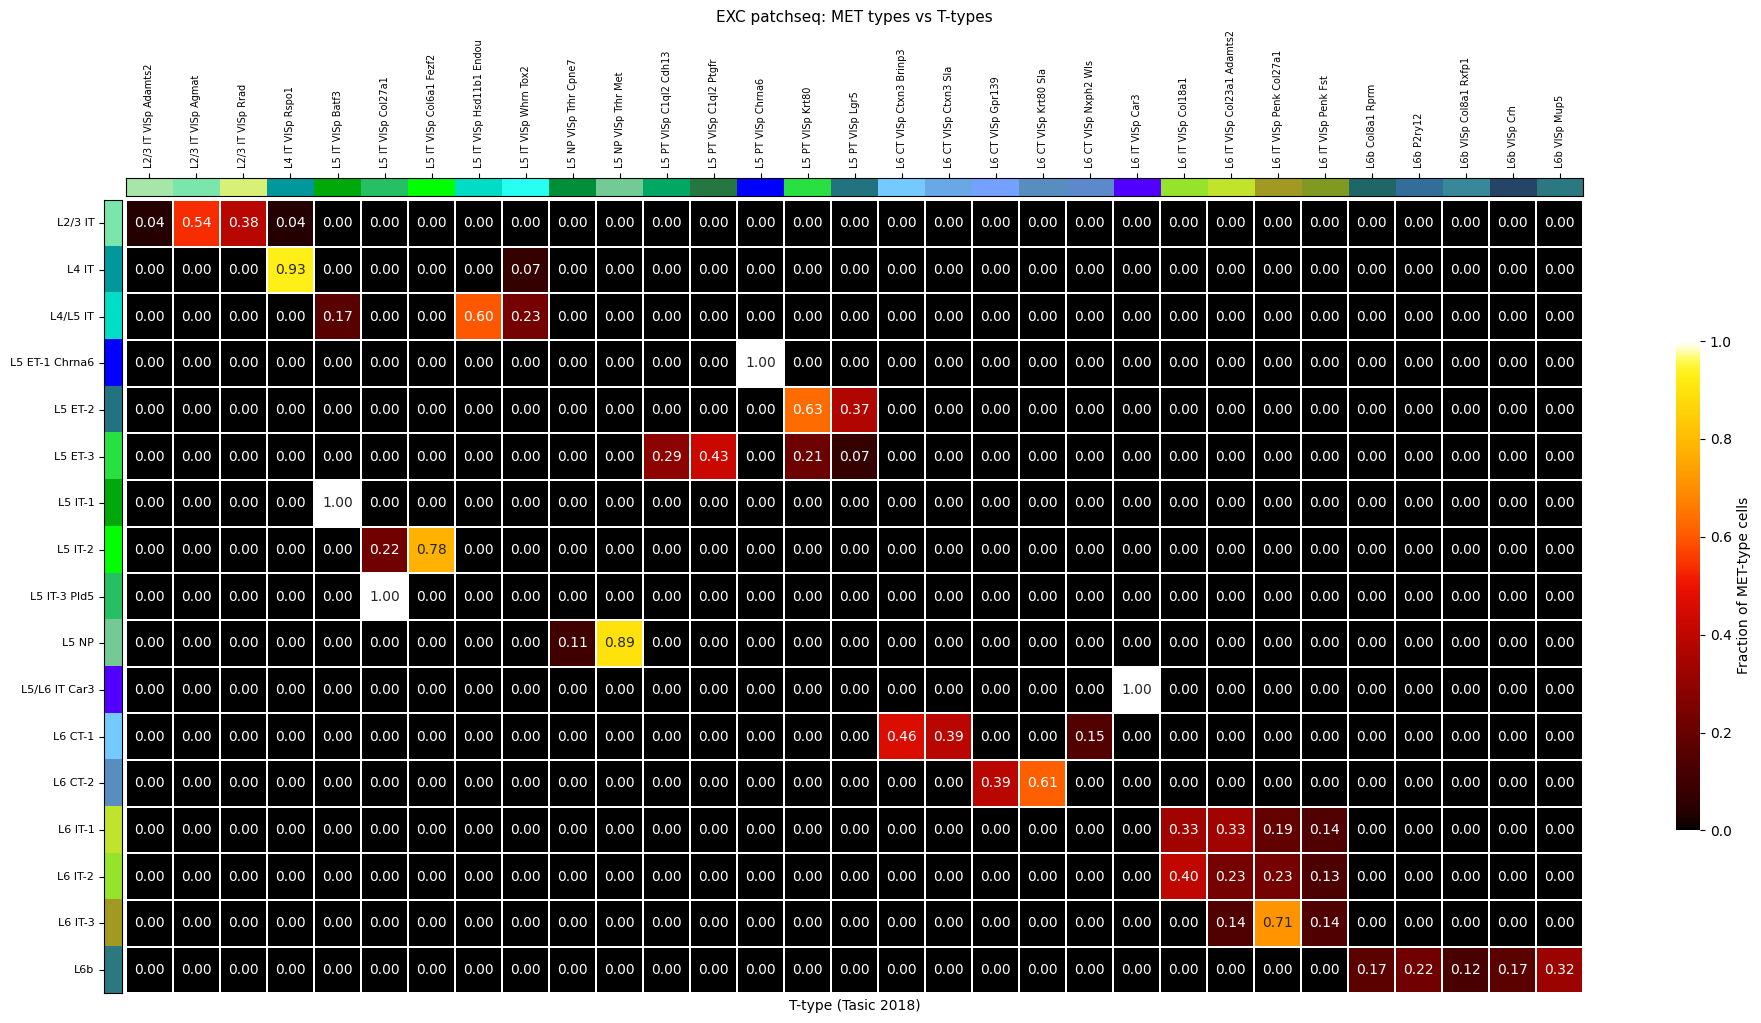

In [33]:
fig_exc = plot_confusion_with_strips(
    patchseq_met_exc_df,
    patchseq_ttype_exc_df,
    met_colors=met_colors,
    ttype_colors=ttype_colors,
    title="EXC patchseq: MET types vs T-types",
)
plt.show()

## 6. INH patchseq cells — MET vs T-type

INH patchseq: MET types vs T-types: 392 cells with both MET and T-type assignments


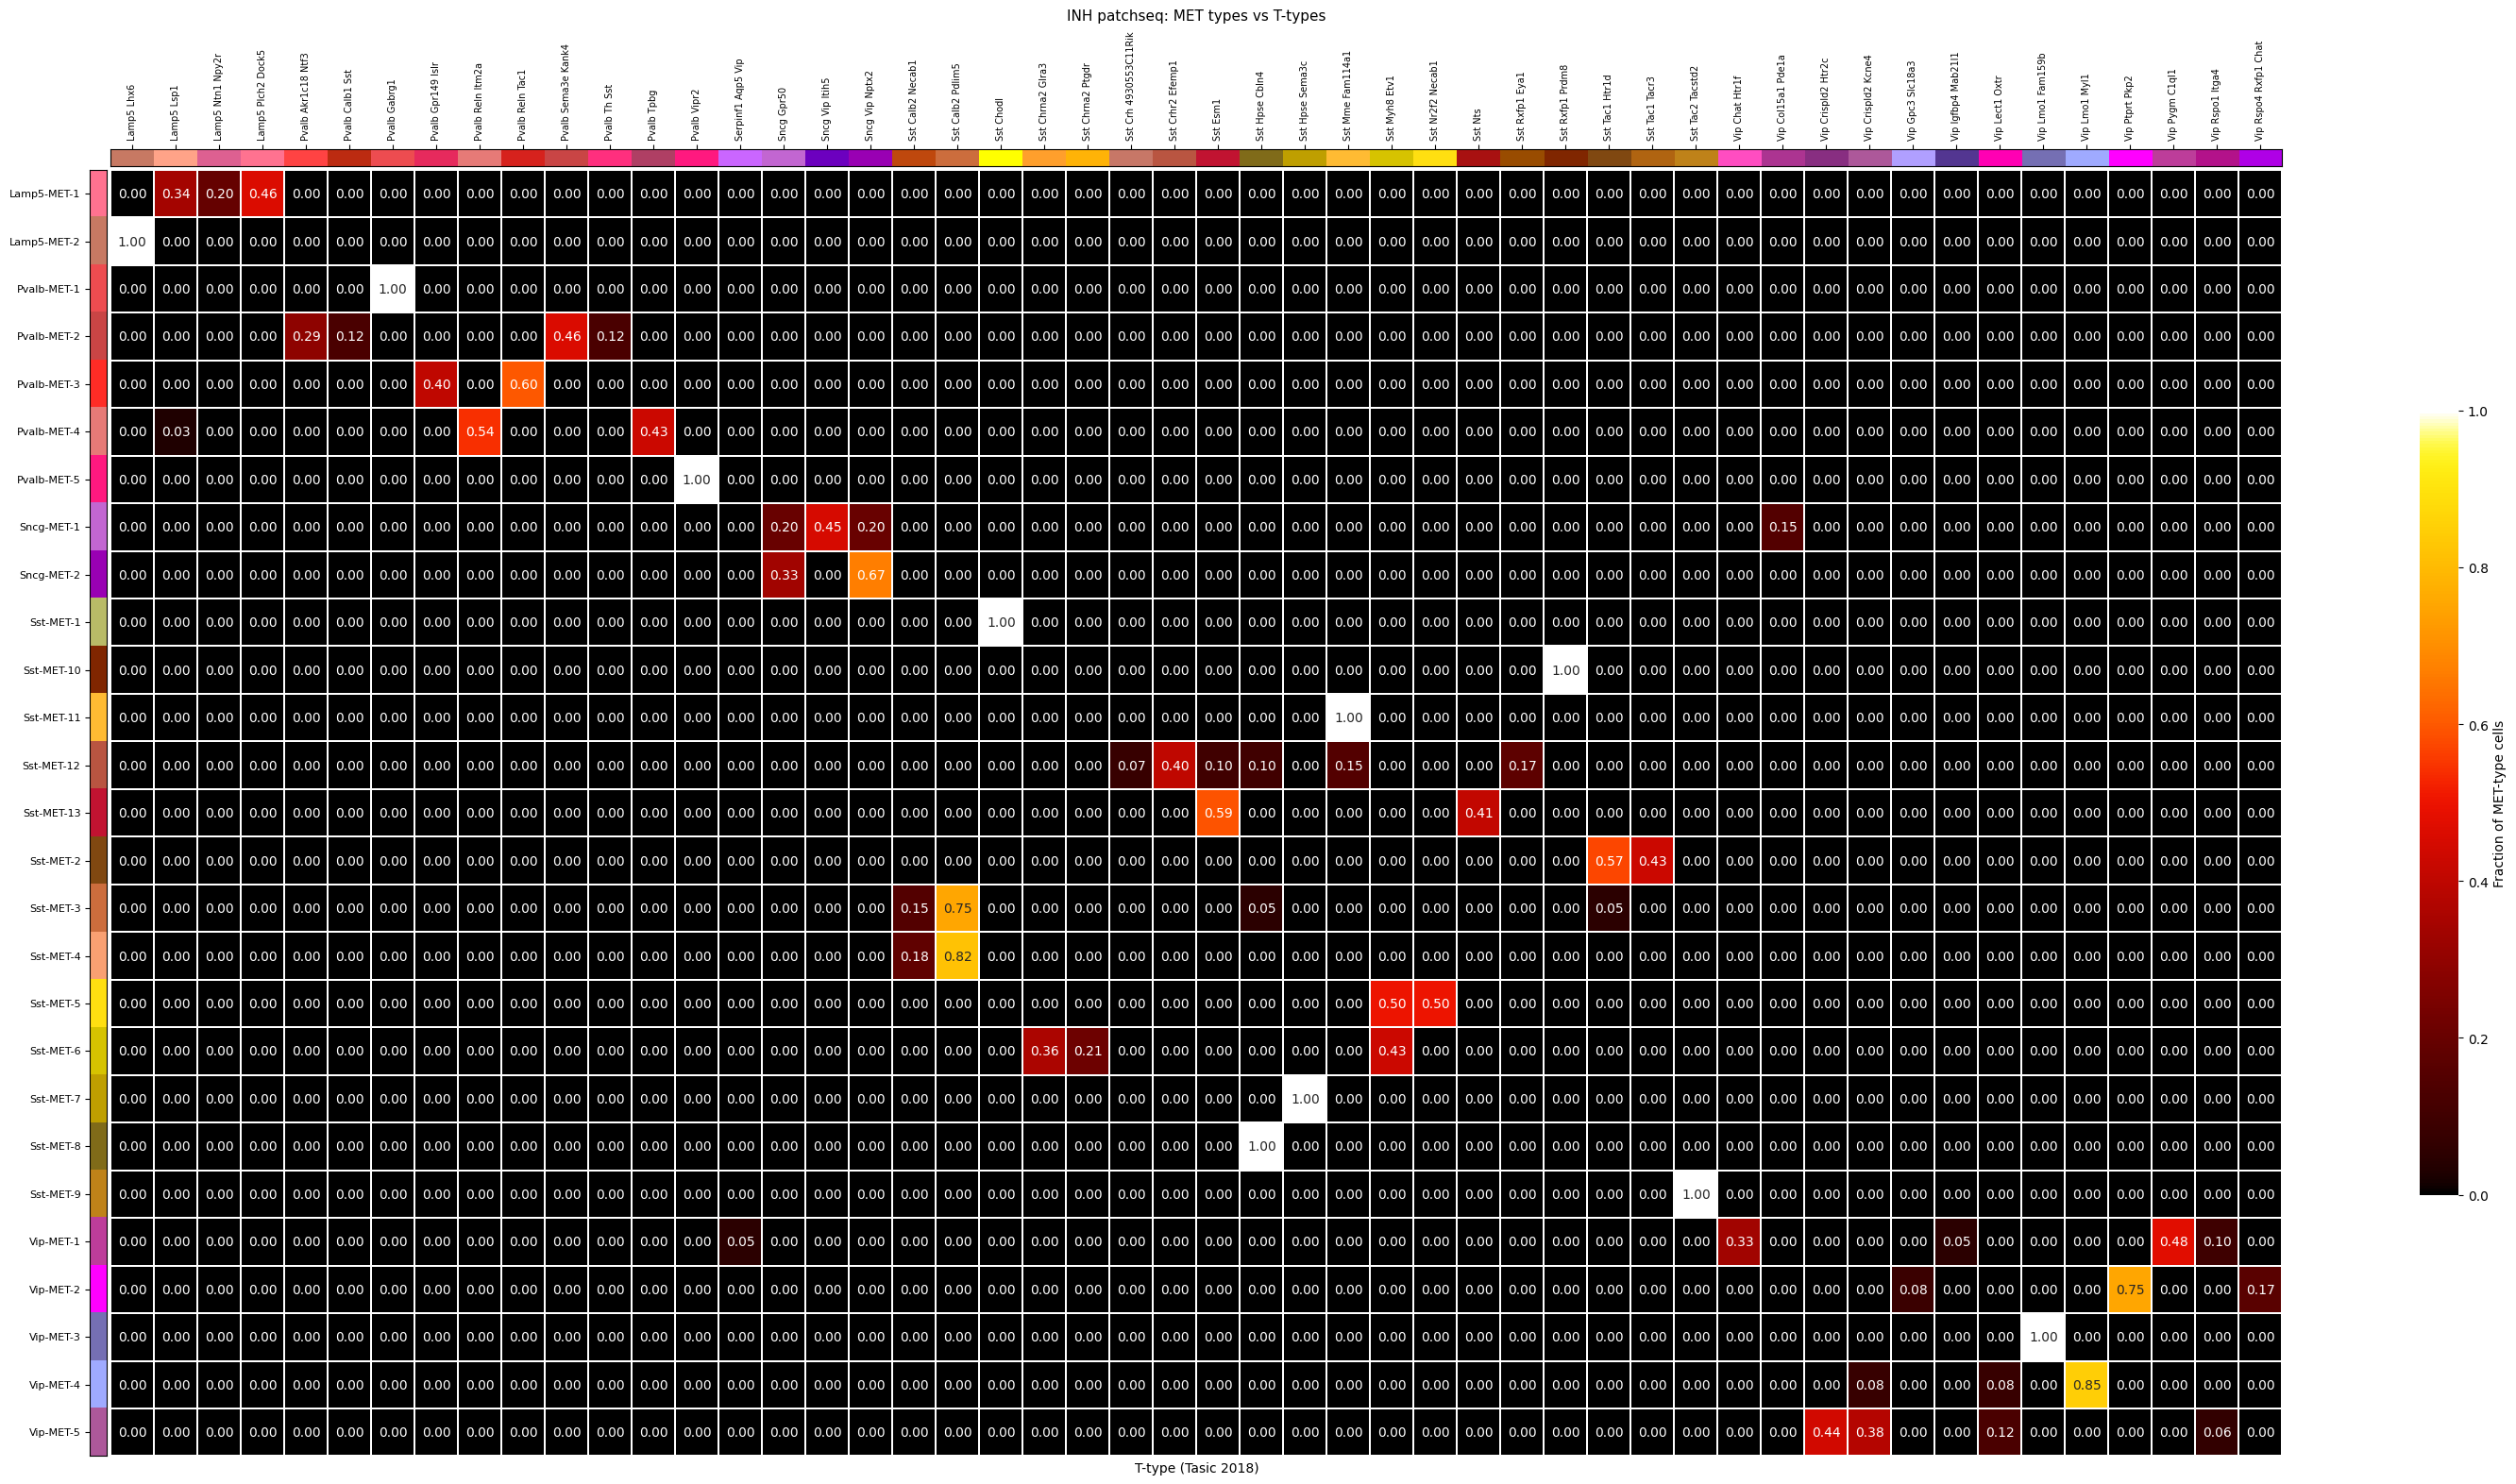

In [34]:
fig_inh = plot_confusion_with_strips(
    patchseq_met_inh_df,
    patchseq_ttype_inh_df,
    met_colors=met_colors,
    ttype_colors=ttype_colors,
    title="INH patchseq: MET types vs T-types",
)
plt.show()

## 7. Combined EXC + INH patchseq cells — MET vs T-type

All patchseq (EXC + INH): MET types vs T-types: 776 cells with both MET and T-type assignments


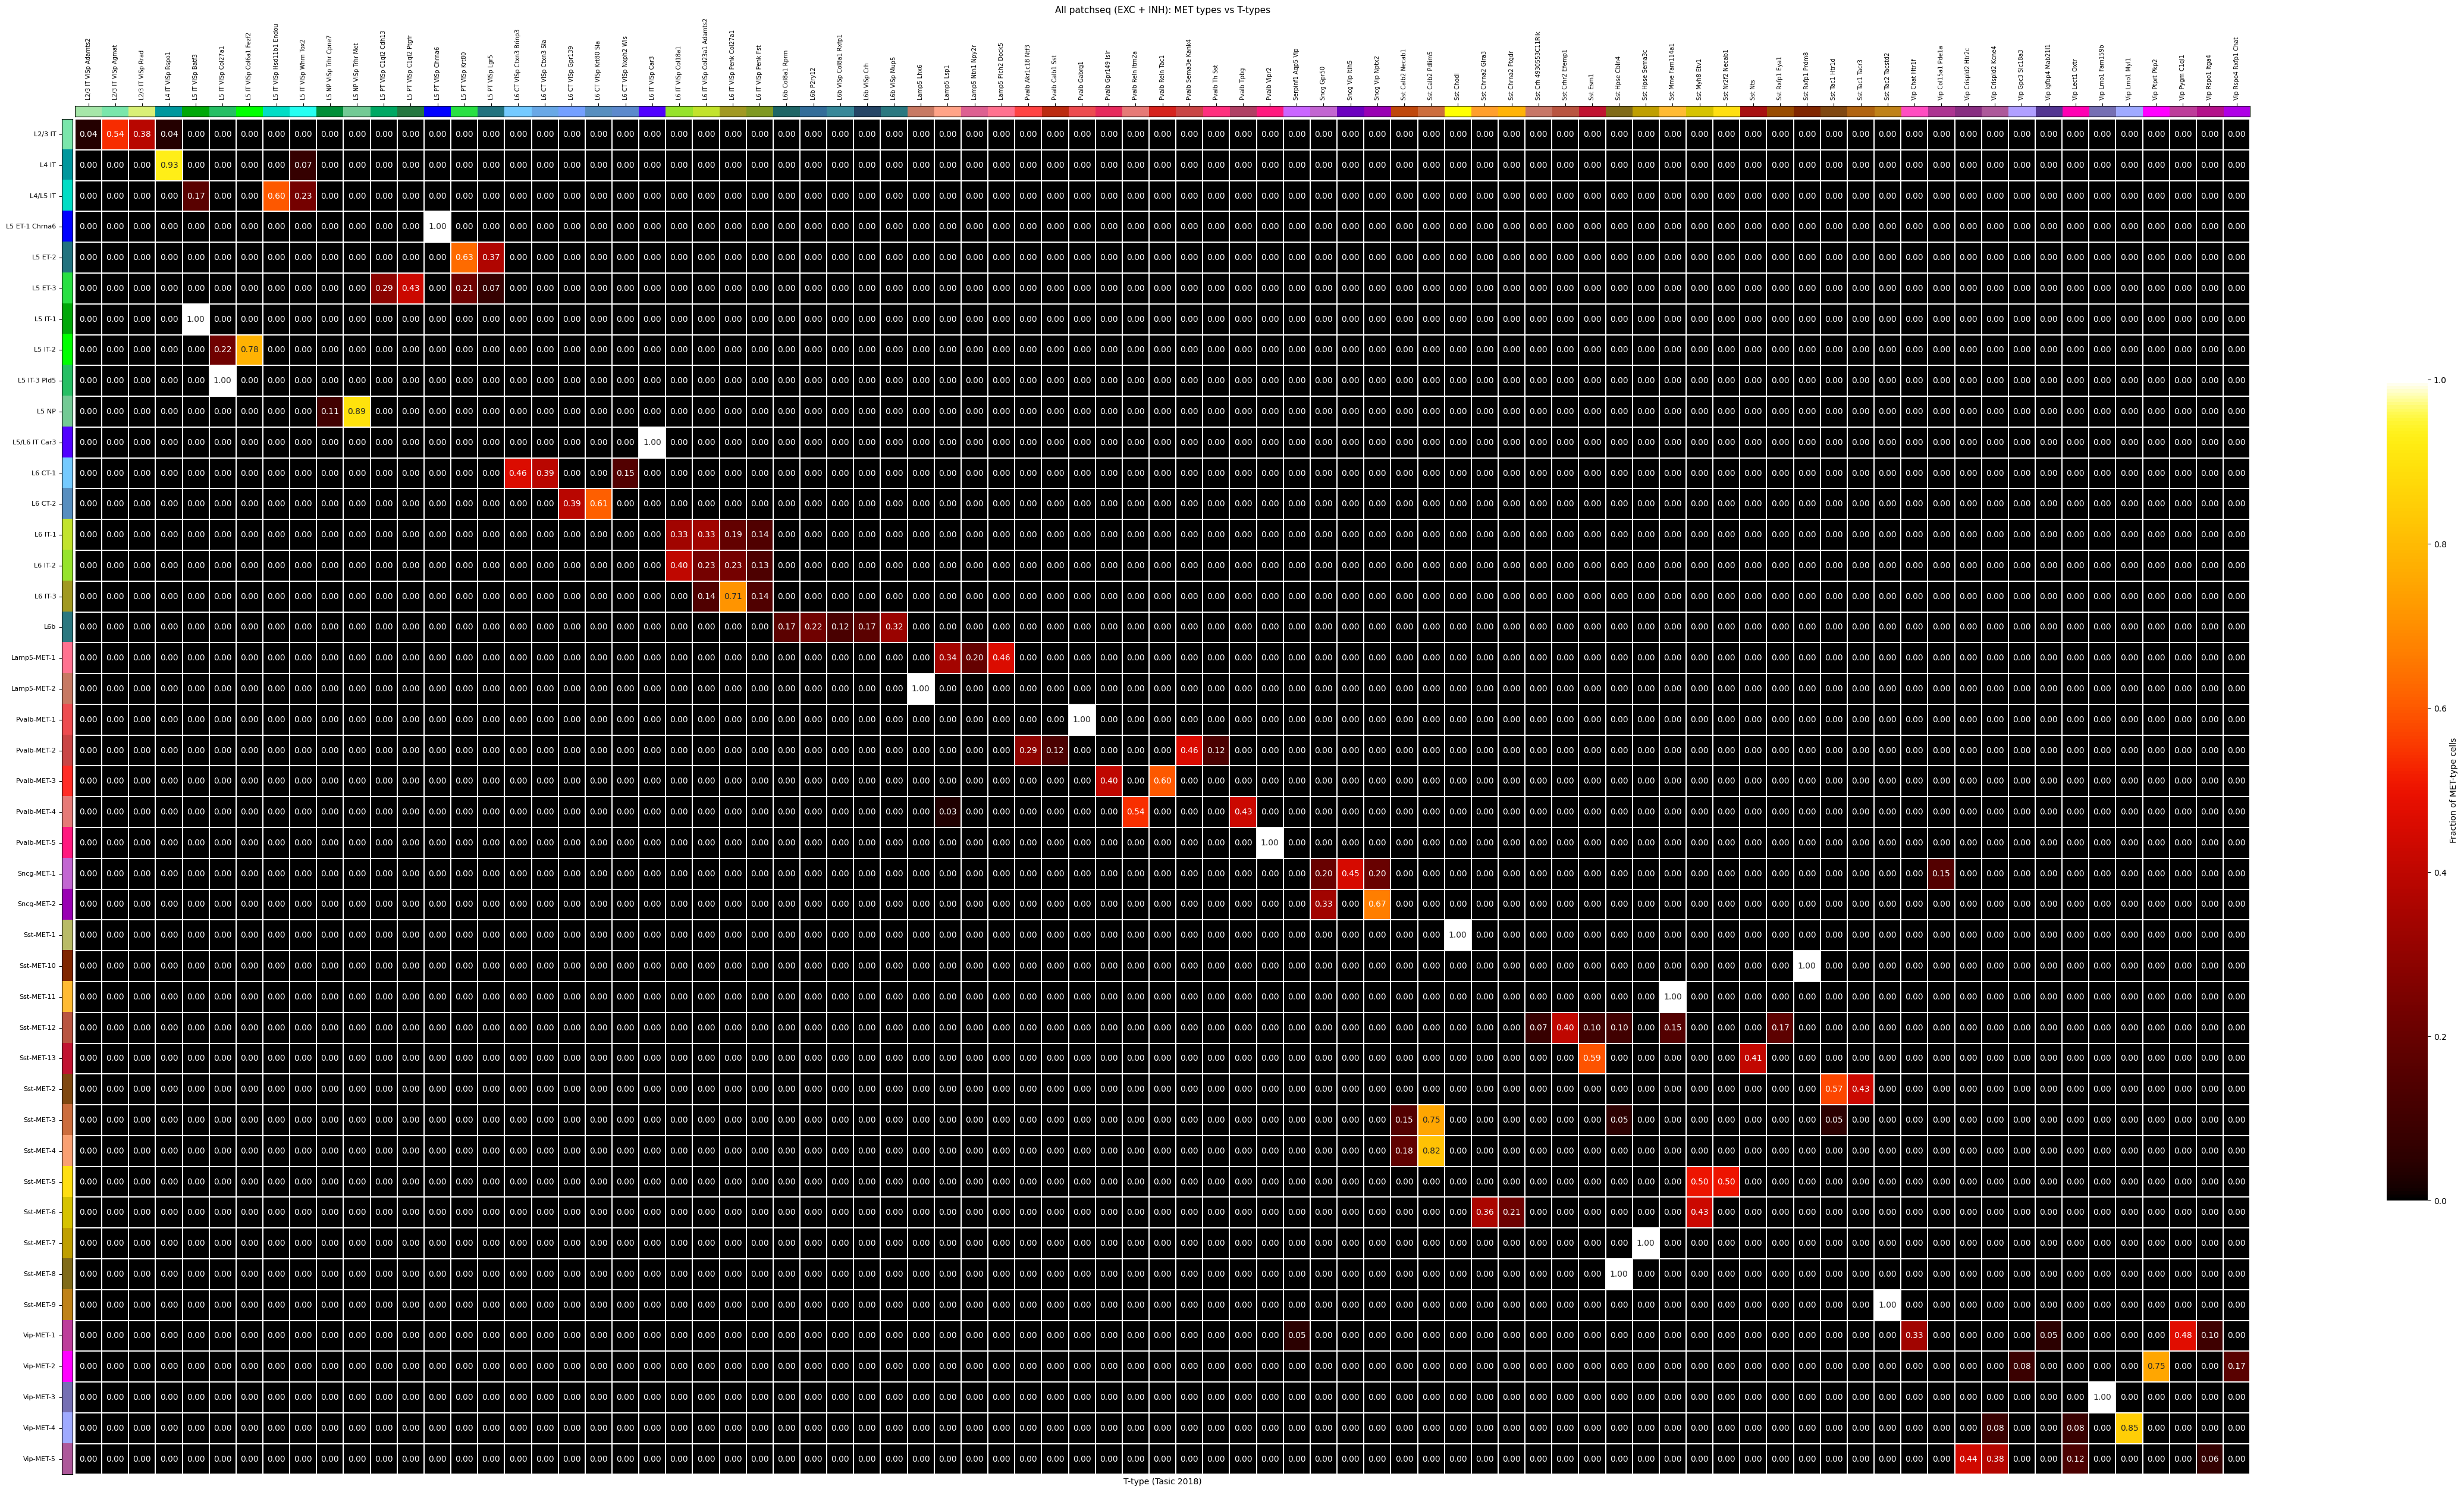

In [35]:
patchseq_met_all_df   = pd.concat([patchseq_met_exc_df,   patchseq_met_inh_df],   ignore_index=True)
patchseq_ttype_all_df = pd.concat([patchseq_ttype_exc_df, patchseq_ttype_inh_df], ignore_index=True)

fig_all = plot_confusion_with_strips(
    patchseq_met_all_df,
    patchseq_ttype_all_df,
    met_colors=met_colors,
    ttype_colors=ttype_colors,
    title="All patchseq (EXC + INH): MET types vs T-types",
)
plt.show()